In [1]:
import numpy as np
from torch.utils.data import Subset
from torchvision import datasets, transforms

# 1. Prepare your dataset (example: CIFAR-10)
tfm = transforms.ToTensor()
full_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
n = len(full_dataset)
print(n)

50000


In [2]:
import os
import glob
from pathlib import Path
import torch
import torch.nn as nn
from Model.ResNet_18 import ResNet18
from Model.VGG16 import ModifiedVGG16
import torch.backends.cudnn as cudnn
import random
import numpy as np
from Dataset.CIFAR_10 import CIFAR10Dataset
from Dataset.CIFAR_100 import CIFAR100Dataset
from torch.utils.data import Subset, DataLoader
import torch.nn.utils.prune as prune

In [3]:
DATASET = ["CIFAR-10"]#"CIFAR-10"]  # , "MNIST", "CIFAR-100"
MODEL = ["VGG16"] #,
SEED = [42]

MODEL_DIR = Path("./saved_models/pruning")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
def load_last_checkpoint(model_dir: Path):
    """
    Load the most recent .pth checkpoint in a model directory.
    Returns the checkpoint path or None if not found.
    """
    ckpt_files = sorted(model_dir.glob("*.pth"), key=os.path.getmtime)
    if not ckpt_files:
        return None
    last_ckpt = ckpt_files[-1]  # the newest one
    #print(f"[📦] Loading last checkpoint: {last_ckpt.name}")
    return last_ckpt

In [5]:
def prune_model_global(model, amount):
    """
    Global unstructured pruning (magnitude-based).
    Removes the `amount` fraction of the smallest-magnitude weights globally.
    """
    # Gather all parameters to prune
    parameters_to_prune = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            parameters_to_prune.append((module, 'weight'))

    # Apply global magnitude pruning
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )

    # Optionally remove the pruning reparameterization (make zeros permanent)
    for module, _ in parameters_to_prune:
        prune.remove(module, 'weight')

    return model

In [11]:
def check_pruned_weights(model):
    """
    Inspect the sparsity (percentage of zero weights) in each pruned layer.
    Also prints global sparsity across the entire model.
    """
    total_weights = 0
    total_zero = 0

    print("\n=== PRUNING CHECKER ===")
    for name, module in model.named_modules():

        # Only examine Conv2d and Linear layers (pruned layers)
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            if hasattr(module, "weight"):
                w = module.weight.data.cpu().numpy()
                num_total = w.size
                num_zero = (w == 0).sum()

                layer_sparsity = num_zero / num_total * 100

                print(f"{name}.weight: zero = {num_zero}/{num_total}  "
                      f"({layer_sparsity:.2f}% sparsity)")

                total_weights += num_total
                total_zero += num_zero

    global_sparsity = total_zero / total_weights * 100
    print(f"\nGLOBAL SPARSITY: {global_sparsity:.2f}%\n")
    return global_sparsity


In [14]:
for dataset in DATASET:
    for model in MODEL:
        for seed in SEED:
            # each run is saved in its own folder, e.g. ./saved_models/CIFAR-10_ResNet-18_45/
            folder_name = f"{dataset}_{model}_{seed}_0.8_FT-AL"
            model_folder = MODEL_DIR / folder_name

            if not model_folder.exists():
                print(f"[⚠️] Missing model folder: {model_folder}")
                continue

            # find last checkpoint
            ckpt_path = load_last_checkpoint(model_folder)
            if ckpt_path is None:
                print(f"[⚠️] No .pth files found in {model_folder}")
                continue
            
            num_classes = 10 if dataset == "CIFAR-10" else 100

In [15]:
ckpt_path

WindowsPath('saved_models/pruning/CIFAR-10_VGG16_42_0.8_FT-AL/epoch_29.pth')

In [16]:
class vgg16_conv_block(nn.Module):
    def __init__(self, input_channels, out_channels, rate=0.3, drop=True):
        super().__init__()
        self.conv = nn.Conv2d(input_channels, out_channels, 3 ,1, 1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(rate)
        self.drop =drop

    def forward(self, x):
        x = self.relu(self.bn(self.conv(x)))
        if self.drop:
            x = self.dropout(x)
        return(x)

def vgg16_layer(input_channels, out_channels, num, dropout=[0.3, 0.3]):
    """
    Creates a sequence of convolutional blocks + maxpool, as in VGG16.
    Args:
        input_channels: input channels to the first block
        out_channels: number of output channels for this layer
        num_blocks: how many conv blocks before pooling
        dropout: [drop_rate_first, drop_rate_later]
    """

    layers = []
    layers.append(vgg16_conv_block(input_channels, out_channels, dropout[0]))
    for i in range(1, num-1):
        layers.append(vgg16_conv_block(out_channels, out_channels, dropout[1]))
    if num>1:
        layers.append(vgg16_conv_block(out_channels, out_channels, drop=False))
    layers.append(nn.MaxPool2d(2,2))
    return(layers)


class ModifiedVGG16(nn.Module):
    """
        Modified VGG16 for CIFAR-10 or CIFAR-100.
        Args:
            num_classes (int): number of output classes (10 or 100 typically)
    """
    def __init__(self, num_classes=100):
        super(ModifiedVGG16, self).__init__()
        self.features = nn.Sequential(*vgg16_layer(3,64,2,[0.3,0.3]), *vgg16_layer(64,128,2),
                                      *vgg16_layer(128,256,3), *vgg16_layer(256,512,3),
                                      *vgg16_layer(512,512,3))
        self.classifier = nn.Sequential(nn.Dropout(0.2), 
                                        nn.Flatten(), 
                                        nn.Linear(512, 512, bias=True),
                                        nn.BatchNorm1d(512), 
                                        nn.ReLU(inplace=True), 
                                        nn.Linear(512,num_classes, bias=True))
         
    def forward(self, x):
        x = self.features(x)
        x = self.classifier[0](x)  
        x = self.classifier[1](x) 
        x = self.classifier[2](x)   
        x = self.classifier[3](x)  
        x = self.classifier[4](x)  
        x = self.classifier[5](x)     
        return x   

In [16]:
state = torch.load(ckpt_path, map_location=DEVICE)
net = ModifiedVGG16(num_classes=num_classes).to(DEVICE)
net.load_state_dict(state)

<All keys matched successfully>

In [13]:
from Model.ResNet_18 import ResNet18

net = ResNet18(num_classes=num_classes).to(DEVICE)
state = torch.load(ckpt_path, map_location=DEVICE)
net.load_state_dict(state)

NameError: name 'num_classes' is not defined

In [17]:
check_pruned_weights(net) # net is the model just after loading


=== PRUNING CHECKER ===
features.0.conv.weight: zero = 76/1728  (4.40% sparsity)
features.1.conv.weight: zero = 7672/36864  (20.81% sparsity)
features.3.conv.weight: zero = 16883/73728  (22.90% sparsity)
features.4.conv.weight: zero = 41031/147456  (27.83% sparsity)
features.6.conv.weight: zero = 96975/294912  (32.88% sparsity)
features.7.conv.weight: zero = 263551/589824  (44.68% sparsity)
features.8.conv.weight: zero = 285942/589824  (48.48% sparsity)
features.10.conv.weight: zero = 724889/1179648  (61.45% sparsity)
features.11.conv.weight: zero = 1931028/2359296  (81.85% sparsity)
features.12.conv.weight: zero = 2036854/2359296  (86.33% sparsity)
features.14.conv.weight: zero = 2151743/2359296  (91.20% sparsity)
features.15.conv.weight: zero = 2158495/2359296  (91.49% sparsity)
features.16.conv.weight: zero = 2176289/2359296  (92.24% sparsity)
classifier.2.weight: zero = 90096/262144  (34.37% sparsity)
classifier.5.weight: zero = 658/5120  (12.85% sparsity)

GLOBAL SPARSITY: 80.00%

np.float64(79.99999732936797)

In [ ]:
for name, param in net.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

In [54]:
net_pr = prune_model_global(net, 0.6)
check_pruned_weights(net_pr) # net_pr is the model just after pruning


=== PRUNING CHECKER ===
features.0.conv.weight: zero = 54/1728  (3.12% sparsity)
features.1.conv.weight: zero = 5413/36864  (14.68% sparsity)
features.3.conv.weight: zero = 11689/73728  (15.85% sparsity)
features.4.conv.weight: zero = 28374/147456  (19.24% sparsity)
features.6.conv.weight: zero = 67408/294912  (22.86% sparsity)
features.7.conv.weight: zero = 185765/589824  (31.49% sparsity)
features.8.conv.weight: zero = 202960/589824  (34.41% sparsity)
features.10.conv.weight: zero = 521254/1179648  (44.19% sparsity)
features.11.conv.weight: zero = 1471341/2359296  (62.36% sparsity)
features.12.conv.weight: zero = 1558108/2359296  (66.04% sparsity)
features.14.conv.weight: zero = 1619861/2359296  (68.66% sparsity)
features.15.conv.weight: zero = 1624414/2359296  (68.85% sparsity)
features.16.conv.weight: zero = 1627798/2359296  (69.00% sparsity)
classifier.2.weight: zero = 61738/262144  (23.55% sparsity)
classifier.5.weight: zero = 460/5120  (8.98% sparsity)

GLOBAL SPARSITY: 60.00%


np.float64(60.000001335316014)

In [ ]:
for name, param in net_pr.named_parameters():
    print(f"{name}: f{param}")

In [ ]:
for name, param in net_pr.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

In [56]:
MODEL_DIR = Path("./saved_models/pruning")

for dataset in DATASET:
    for model in MODEL:
        for seed in SEED:
            # each run is saved in its own folder, e.g. ./saved_models/CIFAR-10_ResNet-18_45/
            folder_name = f"{dataset}_{model}_{seed}_0.8_FT-AL"
            model_folder = MODEL_DIR / folder_name

            if not model_folder.exists():
                print(f"[⚠️] Missing model folder: {model_folder}")
                continue

            # find last checkpoint
            ckpt_path = load_last_checkpoint(model_folder)
            if ckpt_path is None:
                print(f"[⚠️] No .pth files found in {model_folder}")
                continue
            
            num_classes = 10 if dataset == "CIFAR-10" else 100

In [57]:
ckpt_path

WindowsPath('saved_models/pruning/CIFAR-10_VGG16_42_0.8_FT-AL/epoch_9.pth')

In [58]:
state_ft = torch.load(ckpt_path, map_location=DEVICE)
net_ft = ModifiedVGG16(num_classes=num_classes).to(DEVICE)
net_ft.load_state_dict(state_ft)

<All keys matched successfully>

In [59]:
check_pruned_weights(net_ft)


=== PRUNING CHECKER ===
features.0.conv.weight: zero = 76/1728  (4.40% sparsity)
features.1.conv.weight: zero = 7672/36864  (20.81% sparsity)
features.3.conv.weight: zero = 16883/73728  (22.90% sparsity)
features.4.conv.weight: zero = 41031/147456  (27.83% sparsity)
features.6.conv.weight: zero = 96975/294912  (32.88% sparsity)
features.7.conv.weight: zero = 263551/589824  (44.68% sparsity)
features.8.conv.weight: zero = 285942/589824  (48.48% sparsity)
features.10.conv.weight: zero = 724889/1179648  (61.45% sparsity)
features.11.conv.weight: zero = 1931028/2359296  (81.85% sparsity)
features.12.conv.weight: zero = 2036854/2359296  (86.33% sparsity)
features.14.conv.weight: zero = 2151743/2359296  (91.20% sparsity)
features.15.conv.weight: zero = 2158495/2359296  (91.49% sparsity)
features.16.conv.weight: zero = 2176289/2359296  (92.24% sparsity)
classifier.2.weight: zero = 90096/262144  (34.37% sparsity)
classifier.5.weight: zero = 658/5120  (12.85% sparsity)

GLOBAL SPARSITY: 80.00%

np.float64(79.99999732936797)

In [ ]:
for name, param in net.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

In [ ]:
for name, param in net.named_parameters():
    print(f"{name}: f{param}")

# MI Calculation Check

In [42]:
from Dataset.CIFAR_10 import CIFAR10Dataset

dataset_10 = CIFAR10Dataset()

train_set = dataset_10.train_set
test_set = dataset_10.test_set

in_eval_set = dataset_10.in_sample_set

In [4]:
from Dataset.CIFAR_10 import CIFAR10Dataset

dataset_100 = CIFAR100Dataset()

train_set = dataset_100.train_set
test_set = dataset_100.test_set

in_eval_set = dataset_100.in_sample_set

In [5]:
def create_train_subset(train_set, length, seed):
    n = len(train_set)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)

    idx_a, idx_b = perm[:length], perm[length:]

    ds_a = Subset(train_set, idx_a)
    ds_b = Subset(train_set, idx_b)

    # show sizes
    print(f"Created subsets: ds_a={len(ds_a)}, ds_b={len(ds_b)} (total={n})")

    return ds_a, ds_b

In [6]:
train_subset1, train_subset2 = create_train_subset(in_eval_set, 40000, 42)

Created subsets: ds_a=40000, ds_b=10000 (total=50000)


In [7]:
def sample_subset(dataset, sample_size, seed):
    """
    Randomly sample `sample_size` items from a given dataset.
    The selection is reproducible given the same seed.
    """
    n = len(dataset)
    rng = np.random.default_rng(seed)
    indices = rng.choice(n, size=sample_size, replace=False)
    print(len(indices))
    print(indices)
    return Subset(dataset, indices)

In [37]:
train_mask = sample_subset(train_subset1, 10000, seed=42)

10000
[18457 34325 10596 ... 26181 30957  3570]


In [38]:
print(len(train_mask))

10000


In [10]:
DATASET = ["CIFAR-100"]#"CIFAR-10"]  # , "MNIST", "CIFAR-100"
MODEL = ["ResNet-18"] #,
SEED = [46]

MODEL_DIR = Path("./saved_models/normal_new")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
for dataset in DATASET:
    for model in MODEL:
        for seed in SEED:
            # each run is saved in its own folder, e.g. ./saved_models/CIFAR-10_ResNet-18_45/
            folder_name = f"{dataset}_{model}_{seed}"
            model_folder = MODEL_DIR / folder_name

            if not model_folder.exists():
                print(f"[⚠️] Missing model folder: {model_folder}")
                continue

            # find last checkpoint
            ckpt_path = load_last_checkpoint(model_folder)
            if ckpt_path is None:
                print(f"[⚠️] No .pth files found in {model_folder}")
                continue
            
            num_classes = 10 if dataset == "CIFAR-10" else 100

In [15]:
ckpt_path

WindowsPath('saved_models/normal_new/CIFAR-100_ResNet-18_46/epoch_199.pth')

In [17]:
num_classes

100

In [110]:
state = torch.load(ckpt_path, map_location=DEVICE)
net = ModifiedVGG16(num_classes=num_classes).to(DEVICE)
net.load_state_dict(state)

<All keys matched successfully>

In [18]:
from Model.ResNet_18 import ResNet18

net = ResNet18(num_classes=num_classes).to(DEVICE)
state = torch.load(ckpt_path, map_location=DEVICE)
net.load_state_dict(state)

<All keys matched successfully>

In [51]:
trainloader = DataLoader(train_mask, batch_size=128, shuffle=False) # 100 samples

In [20]:
layer_T_array, label_matrix = None, None

import torch.nn.functional as F
# collect layer_T_array for MI analysis
def calculate_MI_input_gpu(layer_T_array, label_matrix, outputs, targets, num_classes):
    outputs_detached = outputs.detach() # [batch, D]
    targets_detached = targets.detach() # [batch]


    # accumulate logits (layer_T_array)
    if layer_T_array is None:
        layer_T_array = outputs_detached
    else:
        layer_T_array = torch.cat((layer_T_array, outputs_detached), dim=0)

    # accumulate one-hot labels on the same device
    batch_onehot = F.one_hot(targets_detached, num_classes=num_classes).float()  # stays on GPU

    if label_matrix is None:
        label_matrix = batch_onehot
    else:
        label_matrix = torch.cat((label_matrix, batch_onehot), dim=0)
    
    return layer_T_array, label_matrix
    
import time

start_time = time.time()
net.eval()
with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = net(inputs)

        layer_T_array, label_matrix = calculate_MI_input_gpu(layer_T_array, label_matrix
                                                        ,outputs, targets, num_classes)



In [357]:
layer_T = torch.softmax(layer_T_array, dim=1)

bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float32)
layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

layer_T = layer_T_discrete.contiguous()
N, C = layer_T.shape

In [359]:
B = num_intervals + 1
powers = B ** torch.arange(C, device=device, dtype=torch.int64)

# Compute hash for every row
hashes = (layer_T * powers).sum(dim=1)  # [N]

# Unique hashes → mark_list & unique patterns
unique_hashes, inverse_indices = torch.unique(hashes, return_inverse=True)

# mark_list[i] tells the unique pattern ID for sample i
mark_list = inverse_indices  # size [N]

K = unique_hashes.size(0)  # number of unique T-values

In [361]:
mark_list

tensor([18,  0, 17, 27, 25, 10, 36, 37, 31, 38,  3, 24, 22, 39, 11, 35, 26, 17,
         2, 30, 16, 32, 33, 21, 33, 23, 20, 15, 28, 31, 14, 36, 34, 12,  4, 17,
         0, 25, 29, 19, 31, 13,  8, 30,  9,  1,  2,  5,  7,  6],
       device='cuda:0')

In [360]:
XT_matrix = torch.zeros((N, K), device=device, dtype=torch.float32)
XT_matrix[torch.arange(N, device=device), mark_list] = 1
XT_matrix = XT_matrix / N  # normalize

# Marginals
P_X_for_layer_T = XT_matrix.sum(dim=1)
P_layer_T_for_X = XT_matrix.sum(dim=0)

In [362]:
P_X_for_layer_T

tensor([0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200], device='cuda:0')

In [363]:
P_layer_T_for_X

tensor([0.0400, 0.0200, 0.0400, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0600,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0400, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0400, 0.0600, 0.0200, 0.0400, 0.0200, 0.0200,
        0.0400, 0.0200, 0.0200, 0.0200], device='cuda:0')

In [350]:
mark_list = torch.zeros(N, dtype=torch.long, device=device)
non_repeat = torch.zeros(N, dtype=torch.long, device=device)
non_repeat_count = 0

In [351]:
XT_matrix_full = torch.zeros((N, N), device=device, dtype=torch.float32)

In [352]:
for i in range(N):
    if i == 0:
        # First row is always unique
        non_repeat[0] = 0
        non_repeat_count = 1
        mark_list[0] = 0
        XT_matrix_full[0, 0] = 1
    else:
        # Compare current row with all non_repeat rows found so far
        # Only look at valid entries: non_repeat[:non_repeat_count]
        nr_indices = non_repeat[:non_repeat_count]
        
        # Vectorized comparison
        matches = torch.all(
            layer_T[i].unsqueeze(0) == layer_T[nr_indices], 
            dim=1
        )
        
        if matches.any():
            # Found a match - use the first one
            match_position = matches.nonzero()[0, 0].item()
            match_idx = nr_indices[match_position].item()
            mark_list[i] = match_idx
            XT_matrix_full[i, match_idx] = 1
        else:
            # New unique pattern
            new_idx = i  # Use actual row index as the unique identifier
            non_repeat[non_repeat_count] = new_idx
            non_repeat_count += 1
            mark_list[i] = new_idx
            XT_matrix_full[i, new_idx] = 1

In [353]:
mark_list

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,  2,
        18, 19, 20, 21, 22, 23, 22, 25, 26, 27, 28,  8, 30,  6, 32, 33, 34,  2,
         1,  4, 38, 39,  8, 41, 42, 19, 44, 45, 18, 47, 48, 49],
       device='cuda:0')

In [348]:
unique_indices, inverse_indices = torch.unique(mark_list, return_inverse=True)

In [338]:
def MI_formula_cal(matrix, p1, p2): #p1, p2 represents marginals
    mask = matrix > 0

    denom = p1[:, None] * p2[None, :]
    
    ratio = matrix / denom
    
    log_ratio = torch.log2(ratio)
    
    MI = (matrix * log_ratio)[mask].sum()

    return MI

def find_match_indices(layer_T, non_repeat, i):
    # layer_T: [N, C]
    # non_repeat: python list of indices
    # returns: mask [len(non_repeat)] of equality with layer_T[i]

    nr_idx = torch.tensor(non_repeat, device=layer_T.device, dtype=torch.long)
    # Compare layer_T[i] to all non_repeat rows at once
    eq = (layer_T[i].unsqueeze(0) == layer_T[nr_idx])   # [len(nonrepeat), C]
    return eq.all(dim=1)  # boolean vector length = len(nonrepeat)

    
def MI_cal_gpu(layer_T, label_matrix, num_intervals=50):
    start_time = time.time()
    device = layer_T.device
    layer_T = torch.softmax(layer_T, dim=1)

    bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float32)
    layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
    layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

    layer_T = layer_T_discrete.contiguous()
    N, C = layer_T.shape

    XT_matrix = torch.zeros((N, N), device=device, dtype=torch.float32)
    non_repeat, mark_list = [], []

    for i in range(N):
        pre_mark_size = len(mark_list)
    
        if i == 0:
            # First row always unique
            non_repeat.append(i)
            mark_list.append(i)
            XT_matrix[i, i] = 1
            continue
    
        matches = find_match_indices(layer_T, non_repeat, i)
    
        if matches.any():
            j = matches.nonzero()[0].item()  # First matched index in non_repeat
            match_idx = non_repeat[j]
            mark_list.append(match_idx)
            XT_matrix[i, match_idx] = 1
        else:
            # No match found → new unique pattern
            new_idx = non_repeat[-1] + 1
            non_repeat.append(new_idx)
            mark_list.append(new_idx)
            XT_matrix[i, new_idx] = 1

    N_unique = len(non_repeat)
    XT_matrix = XT_matrix[:, :N_unique]
    XT_matrix = XT_matrix / N

    P_X_for_layer_T = XT_matrix.sum(dim=1)
    P_layer_T_for_X = XT_matrix.sum(dim=0)

    I_X_T = MI_formula_cal(XT_matrix, P_X_for_layer_T, P_layer_T_for_X)

    mark_t = torch.tensor(mark_list, device=device, dtype=torch.long)
    K = len(non_repeat)
    
    TY_matrix = torch.zeros((K, label_matrix.shape[1]), 
                            device=device, dtype=torch.float32)
    
    TY_matrix.index_add_(0, mark_t, label_matrix)
    
    TY_matrix = TY_matrix / N

    P_layer_T_for_Y = TY_matrix.sum(dim=1)
    P_Y_for_layer_T = TY_matrix.sum(dim=0)

    I_T_Y = MI_formula_cal(TY_matrix, P_layer_T_for_Y, P_Y_for_layer_T)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(elapsed_time)

    return I_X_T.item(), I_T_Y.item()

    

In [333]:
I_X_T, I_T_Y = MI_cal_gpu(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
                          num_intervals=50)

12.19102954864502


In [334]:
print(I_X_T)
print(I_T_Y)

7.9234185218811035
6.5947771072387695


In [254]:
layer_T_array = layer_T_array.to(device=DEVICE, dtype=torch.float64)
label_matrix = label_matrix.to(device=DEVICE, dtype=torch.float64)
layer_T = torch.softmax(layer_T_array, dim=1)
device = layer_T.device

bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float64)
layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

In [255]:
import torch

# layer_T: [N, C], already on GPU (torch.float or torch.int)
# N = NUM_TEST_MASK
layer_T = layer_T_discrete.contiguous()
N, C = layer_T.shape

# Prepare outputs
XT_matrix = torch.zeros((N, N), device=layer_T.device, dtype=torch.float64)
non_repeat = []
mark_list = []

eq_matrix = (layer_T.unsqueeze(1) == layer_T.unsqueeze(0)).all(dim=-1)

for i in range(N):
    pre_mark_size = len(mark_list)

    if i == 0:
        # First row always unique
        non_repeat.append(i)
        mark_list.append(i)
        XT_matrix[i, i] = 1
        continue

    # ---- GPU Vectorized matching ----
    # Compare row i to all existing non_repeat rows
    nonrep_indices = torch.tensor(non_repeat, device=layer_T.device, dtype=torch.long)
    matches = eq_matrix[i, nonrep_indices]  # vector of True/False

    # If match exists
    if matches.any():
        j = matches.nonzero()[0].item()  # First matched index in non_repeat
        match_idx = non_repeat[j]
        mark_list.append(match_idx)
        XT_matrix[i, match_idx] = 1
    else:
        # No match found → new unique pattern
        new_idx = non_repeat[-1] + 1
        non_repeat.append(new_idx)
        mark_list.append(new_idx)
        XT_matrix[i, new_idx] = 1
    

In [256]:
print(mark_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 22, 24, 25, 26, 27, 8, 28, 29, 30, 31, 32, 17, 1, 4, 33, 34, 8, 10, 14, 19, 35, 36, 18, 37, 38, 34]


In [257]:
print(mark_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 22, 24, 25, 26, 27, 8, 28, 29, 30, 31, 32, 17, 1, 4, 33, 34, 8, 10, 14, 19, 35, 36, 18, 37, 38, 34]


In [258]:
print(non_repeat)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


In [259]:
XT_matrix

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0', dtype=torch.float64)

In [260]:
N_unique = len(non_repeat)

# ---- Slice columns (equivalent to np.delete) ----
XT_matrix = XT_matrix[:, :N_unique]

# ---- Normalize ----
XT_matrix = XT_matrix / N

In [ ]:
XT_matrix

In [262]:
XT_matrix.shape

torch.Size([50, 39])

In [263]:
P_X_for_layer_T = XT_matrix.sum(dim=1)
P_layer_T_for_X = XT_matrix.sum(dim=0)

In [264]:
P_layer_T_for_X

tensor([0.0200, 0.0400, 0.0200, 0.0200, 0.0400, 0.0200, 0.0200, 0.0200, 0.0600,
        0.0200, 0.0400, 0.0200, 0.0200, 0.0200, 0.0400, 0.0200, 0.0200, 0.0400,
        0.0400, 0.0400, 0.0200, 0.0200, 0.0400, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0400, 0.0200,
        0.0200, 0.0200, 0.0200], device='cuda:0', dtype=torch.float64)

In [265]:
mask = XT_matrix > 0

denom = P_X_for_layer_T[:, None] * P_layer_T_for_X[None, :]
ratio = XT_matrix / denom

log_ratio = torch.log2(ratio)

MI_XT = (XT_matrix * log_ratio)[mask].sum()

In [266]:
mark_t = torch.tensor(mark_list, device=device, dtype=torch.long)
K = len(non_repeat)

# ---- Build TY matrix via GPU scatter-add ----
TY_matrix = torch.zeros((K, label_matrix.shape[1]), 
                        device=device, dtype=torch.float64)

TY_matrix.index_add_(0, mark_t, label_matrix)

# ---- Normalize ----
TY_matrix = TY_matrix / NUM_TEST_MASK

# ---- Marginals ----
P_layer_T_for_Y = TY_matrix.sum(dim=1)
P_Y_for_layer_T = TY_matrix.sum(dim=0)

In [267]:
P_layer_T_for_Y.shape

torch.Size([39])

In [268]:
# Mask out zero entries (same as if TY[i,j]==0: pass)
mask = TY_matrix > 0

# Compute PT[t] * PY[y] denominator: broadcast to [K, L]
denom = P_layer_T_for_Y[:, None] * P_Y_for_layer_T[None, :]

# Ratio TY / (PT * PY)
ratio = TY_matrix / denom

# log2(ratio)
log_ratio = torch.log2(ratio)

# Compute MI(T;Y)
MI_TY = (TY_matrix * log_ratio)[mask].sum()

In [271]:
MI_XT.item()

5.188758439731455

In [270]:
MI_TY

tensor(5.0386, device='cuda:0', dtype=torch.float64)

In [200]:
EPS = 1e-10

layer_T_array = torch.softmax(layer_T_array, dim=1)

NUM_INTERVALS = 50
bins = torch.linspace(0, 1, NUM_INTERVALS + 1, device=DEVICE, dtype=torch.float64)
layer_T_discrete = torch.bucketize(layer_T_array, bins, right=True) - 1
layer_T_discrete = layer_T_discrete.clamp(0, NUM_INTERVALS - 1)

In [199]:
layer_T_array.shape

torch.Size([50, 100])

In [202]:
layer_T_discrete.shape

torch.Size([50, 100])

In [179]:
layer_T_array # this step the same

tensor([[5.5215e-07, 1.6568e-05, 1.6823e-05,  ..., 1.1000e-06, 5.1836e-07,
         1.8038e-06],
        [1.8368e-06, 2.3461e-05, 2.4118e-06,  ..., 6.3186e-06, 1.1586e-05,
         2.0450e-05],
        [3.6254e-04, 1.3708e-04, 7.1572e-05,  ..., 4.8803e-04, 1.2392e-04,
         1.5322e-03],
        ...,
        [4.6519e-04, 1.3855e-04, 2.2083e-04,  ..., 4.5470e-04, 2.3677e-04,
         6.3568e-04],
        [9.4465e-06, 5.8646e-06, 5.5570e-06,  ..., 9.9638e-01, 8.5688e-06,
         3.3189e-05],
        [1.1803e-06, 2.9617e-06, 1.4884e-05,  ..., 9.6174e-07, 5.5830e-06,
         2.1333e-04]], device='cuda:0')

In [ ]:
bins = torch.linspace(0, 1, NUM_INTERVALS + 1, device=DEVICE, dtype=torch.float64)

print(bins)
print(len(bins))

In [ ]:
layer_T_discrete[22:32] 

In [182]:
layer_T_discrete = layer_T_discrete.clamp(0, NUM_INTERVALS - 1)

In [183]:
Non_repeat_patterns, mark_list = torch.unique(layer_T_discrete, dim=0, return_inverse=True)

In [171]:
Non_repeat_patterns

tensor([[ 0,  0,  0,  ...,  0,  0, 49],
        [ 0,  0,  0,  ..., 49,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        ...,
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0, 49,  0,  ...,  0,  0,  0]], device='cuda:0')

In [173]:
num_unique_patterns = Non_repeat_patterns.shape[0]
print(num_unique_patterns)

39


In [184]:
mark_list

tensor([15, 25, 11, 31, 23, 18, 35, 34, 29, 20, 33, 36, 38, 22,  4,  0, 13, 12,
         5, 16,  3,  8, 10, 28, 10, 37,  6, 19,  2, 29,  9, 26, 17, 21,  7, 12,
        25, 23, 14, 30, 29, 33,  4, 16, 24, 27,  5, 32,  1,  7],
       device='cuda:0')

In [193]:
N, C = layer_T.shape
device = layer_T.device

# Step 1: full match matrix
match_matrix = (layer_T.unsqueeze(1) == layer_T.unsqueeze(0)).all(dim=2)   # [N, N]

# Step 2: first matching row index for each row (first True along row)
first_match = match_matrix.float().argmax(dim=1)   # [N]

# Step 3: convert first_match indices into increasing group IDs
# unique() returns sorted unique values and inverse maps each row to its group
unique_first, group_ids = torch.unique(first_match, sorted=True, return_inverse=True)
# group_ids[i] = group number for row i, matching your Non_repeat logic

# Step 4: build XT_matrix
XT_matrix = torch.zeros((N, unique_first.numel()), device=device)
XT_matrix[torch.arange(N, device=device), group_ids] = 1

In [195]:
unique_first

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63], device='cuda:0')

In [196]:
group_ids

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63], device='cuda:0')

In [194]:
XT_matrix

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]], device='cuda:0')

In [ ]:
device = layer_T_array.device
NUM_TEST_MASK = 50

equality_matrix = torch.all(
        layer_T.unsqueeze(0) == layer_T.unsqueeze(1), 
        dim=2
    ).float()

triu_mask = torch.triu(torch.ones(NUM_TEST_MASK, NUM_TEST_MASK, device=device))
equality_matrix = equality_matrix * triu_mask

equality_matrix_with_large = equality_matrix + (1 - triu_mask) * 1e9
first_match_indices = torch.argmin(
    torch.where(equality_matrix > 0, 
               torch.arange(NUM_TEST_MASK, device=device).float().unsqueeze(0).expand(NUM_TEST_MASK, -1),
               torch.tensor(1e9, device=device)),
    dim=1
)

XT_matrix = torch.zeros((NUM_TEST_MASK, NUM_TEST_MASK), device=device)
XT_matrix[torch.arange(NUM_TEST_MASK, device=device), first_match_indices] = 1

In [138]:
value_xt, value_ty = MI_cal_gpu_exact(label_matrix, layer_T_array, NUM_TEST_MASK=40000)
end_time = time.time()
elapsed_time = end_time - start_time

print(value_xt)
print(value_ty)
print(f"Time taken: {elapsed_time:.4f} seconds")

GPU Time: 0.011999s
7.843516826629639
6.615174770355225
Time taken: 410.0664 seconds


In [96]:
N, D = layer_T_array.shape
NUM_LABEL = label_matrix.shape[1]

In [ ]:
layer_T_array = torch.softmax(layer_T_array, dim=1)
print(layer_T_array)

In [ ]:
num_intervals = 50
bins = torch.linspace(0, 1, num_intervals + 1, device=DEVICE)
disc_T = torch.bucketize(layer_T_array, bins) - 1   # output: [0 .. num_intervals-1]

print(bins)
print(disc_T)

In [100]:
K = unique_codes.shape[0]
print(K)

16


In [101]:
p_xt = counts.float() / N
print(p_xt)

tensor([0.0400, 0.0700, 0.1100, 0.1000, 0.0100, 0.1300, 0.0100, 0.1400, 0.0100,
        0.0800, 0.0100, 0.0800, 0.1100, 0.0100, 0.0100, 0.0800],
       device='cuda:0')


In [89]:
print(layer_T_array.shape)

torch.Size([100, 10])


In [90]:
NUM_LABEL = label_matrix.shape[1]
NUM_LABEL

10

In [63]:
value_xt, value_ty = MI_fast_torch(label_matrix, layer_T_array)

cuda:0


In [64]:
print(value_xt)
print(value_ty)

4.094301223754883
3.3177995681762695


In [24]:
layer_T_array, label_matrix = None, None

import torch.nn.functional as F
# collect layer_T_array for MI analysis
def calculate_MI_input_gpu(layer_T_array, label_matrix, outputs, targets, num_classes):
    outputs_detached = outputs.detach() # [batch, D]
    targets_detached = targets.detach() # [batch]


    # accumulate logits (layer_T_array)
    if layer_T_array is None:
        layer_T_array = outputs_detached
    else:
        layer_T_array = torch.cat((layer_T_array, outputs_detached), dim=0)

    # accumulate one-hot labels on the same device
    batch_onehot = F.one_hot(targets_detached, num_classes=num_classes).float()  # stays on GPU

    if label_matrix is None:
        label_matrix = batch_onehot
    else:
        label_matrix = torch.cat((label_matrix, batch_onehot), dim=0)
    
    return layer_T_array, label_matrix
    
import time

start_time = time.time()
net.eval()
with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = net(inputs)

        layer_T_array, label_matrix = calculate_MI_input_gpu(layer_T_array, label_matrix
                                                        ,outputs, targets, num_classes)



In [295]:
I_X_T, I_T_Y = MI_cal_gpu_vectorized(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
                          num_intervals=50)

[MI_cal_gpu_vectorized] time: 0.2690s


In [296]:
print(I_X_T)
print(I_T_Y)

7.843517332093332
6.615235583590202


In [302]:
layer_T = torch.softmax(layer_T_array, dim=1)

bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float64)
layer_T_disc = torch.bucketize(layer_T, bins, right=True) - 1

In [303]:
layer_T_disc

tensor([[ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        ...,
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ..., 49,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0]], device='cuda:0')

In [304]:
layer_T_disc = layer_T_disc.clamp(0, num_intervals - 1).contiguous()  # [N, C], int

In [305]:
N, C = layer_T_disc.shape

In [306]:
hashes = hash_rows_int(layer_T_disc)  # [N]

In [307]:
hashes

tensor([260356551,  81647377,  55520298, 421112517, 198840530, 191056537,
        103006612, 484779834, 454722744,  76720329, 170146571, 121409358,
        231049945, 255296272, 227971128, 389736690, 250242853,  59141187,
        370694408, 117606076, 269459085,  64229935, 199551128, 228478523,
        199551128, 281644552, 288923012, 435574230, 351267427, 454722744,
        176870351, 155482341,  68616415, 157285051,  72457770,  59141187,
         81647377, 198840530, 203231665,  81210903, 454722744, 170146571,
        227971128, 117606076, 282361038, 147909255, 370694408, 370361656,
        141681736,  72457770], device='cuda:0')

In [308]:
sorted_hashes, order = torch.sort(hashes)

In [310]:
sorted_hashes

tensor([ 55520298,  59141187,  59141187,  64229935,  68616415,  72457770,
         72457770,  76720329,  81210903,  81647377,  81647377, 103006612,
        117606076, 117606076, 121409358, 141681736, 147909255, 155482341,
        157285051, 170146571, 170146571, 176870351, 191056537, 198840530,
        198840530, 199551128, 199551128, 203231665, 227971128, 227971128,
        228478523, 231049945, 250242853, 255296272, 260356551, 269459085,
        281644552, 282361038, 288923012, 351267427, 370361656, 370694408,
        370694408, 389736690, 421112517, 435574230, 454722744, 454722744,
        454722744, 484779834], device='cuda:0')

In [311]:
order

tensor([ 2, 17, 35, 21, 32, 34, 49,  9, 39,  1, 36,  6, 19, 43, 11, 48, 45, 31,
        33, 10, 41, 30,  5,  4, 37, 22, 24, 38, 14, 42, 23, 12, 16, 13,  0, 20,
        25, 44, 26, 28, 47, 18, 46, 15,  3, 27,  8, 29, 40,  7],
       device='cuda:0')

In [312]:
is_new = torch.ones(N, device=device, dtype=torch.bool)

In [313]:
is_new

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True], device='cuda:0')

In [314]:
is_new[1:] = (sorted_hashes[1:] != sorted_hashes[:-1])

In [315]:
is_new

tensor([ True,  True, False,  True,  True,  True, False,  True,  True,  True,
        False,  True,  True, False,  True,  True,  True,  True,  True,  True,
        False,  True,  True,  True, False,  True, False,  True,  True, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True, False, False,  True],
       device='cuda:0')

In [317]:
unique_ids_sorted = is_new.cumsum(dim=0) - 1  # [N]

In [321]:
unique_ids_sorted

tensor([ 0,  1,  1,  2,  3,  4,  4,  5,  6,  7,  7,  8,  9,  9, 10, 11, 12, 13,
        14, 15, 15, 16, 17, 18, 18, 19, 19, 20, 21, 21, 22, 23, 24, 25, 26, 27,
        28, 29, 30, 31, 32, 33, 33, 34, 35, 36, 37, 37, 37, 38],
       device='cuda:0')

In [322]:
mark_list = torch.empty_like(unique_ids_sorted)
print(mark_list)

tensor([ 1,  2,  2,  3,  4,  5,  5,  6,  7,  8,  8,  9, 10, 10, 11, 12, 13, 14,
        15, 16, 16, 17, 18, 19, 19, 20, 20, 21, 22, 22, 23, 24, 25, 26, 27, 28,
        29, 30, 31, 32, 33, 34, 34, 35, 36, 37, 38, 38, 38, 39],
       device='cuda:0')


In [323]:
mark_list = torch.empty_like(unique_ids_sorted)
mark_list[order] = unique_ids_sorted  # [N], int cluster for each sample

K = (unique_ids_sorted[-1] + 1).item()

In [324]:
mark_list

tensor([26,  7,  0, 35, 18, 17,  8, 38, 37,  5, 15, 10, 23, 25, 21, 34, 24,  1,
        33,  9, 27,  2, 19, 22, 19, 28, 30, 36, 31, 37, 16, 13,  3, 14,  4,  1,
         7, 18, 20,  6, 37, 15, 21,  9, 29, 12, 33, 32, 11,  4],
       device='cuda:0')

In [339]:
layer_T = layer_T_array

N, C = layer_T.shape
device = layer_T.device

In [340]:
uniques, inverse = torch.unique(layer_T, dim=0, sorted=True, return_inverse=True)

In [365]:
import torch
import time

def MI_formula_cal(matrix, p1, p2):  # p1, p2 = marginals
    mask = matrix > 0
    denom = p1[:, None] * p2[None, :]
    ratio = matrix / denom
    log_ratio = torch.log2(ratio)
    MI = (matrix * log_ratio)[mask].sum()
    return MI


def MI_cal_gpu(layer_T, label_matrix, num_intervals=50):
    """
    Optimized version:
        – identical math logic to your original MI_cal_gpu
        – uses GPU hashing to remove Python loops
        – produces identical or extremely similar results
    """

    start_time = time.time()
    device = layer_T.device

    # ---------------------------------------------------------
    # Step 1 — Softmax → bucketization (same as original logic)
    # ---------------------------------------------------------
    layer_T = torch.softmax(layer_T, dim=1)

    bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float32)
    layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
    layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

    layer_T = layer_T_discrete.contiguous().to(torch.int64)
    N, C = layer_T.shape

    # ---------------------------------------------------------
    # Step 2 — GPU hashing to detect unique T-patterns
    #         (replaces slow Python loop)
    # ---------------------------------------------------------
    B = num_intervals + 1
    powers = B ** torch.arange(C, device=device, dtype=torch.int64)

    # Compute hash for every row
    hashes = (layer_T * powers).sum(dim=1)  # [N]

    # Unique hashes → mark_list & unique patterns
    unique_hashes, inverse_indices = torch.unique(hashes, return_inverse=True)

    # mark_list[i] tells the unique pattern ID for sample i
    mark_list = inverse_indices  # size [N]

    K = unique_hashes.size(0)  # number of unique T-values

    # ---------------------------------------------------------
    # Step 3 — Build XT_matrix (same definition as before)
    # ---------------------------------------------------------
    XT_matrix = torch.zeros((N, K), device=device, dtype=torch.float32)
    XT_matrix[torch.arange(N, device=device), mark_list] = 1
    XT_matrix = XT_matrix / N  # normalize

    # Marginals
    P_X_for_layer_T = XT_matrix.sum(dim=1)
    P_layer_T_for_X = XT_matrix.sum(dim=0)

    # ---------------------------------------------------------
    # Step 4 — I(X ; T)
    # ---------------------------------------------------------
    I_X_T = MI_formula_cal(XT_matrix, P_X_for_layer_T, P_layer_T_for_X)

    # ---------------------------------------------------------
    # Step 5 — Build TY_matrix same as before
    # ---------------------------------------------------------
    TY_matrix = torch.zeros((K, label_matrix.shape[1]), 
                            device=device, dtype=torch.float32)

    TY_matrix.index_add_(0, mark_list, label_matrix)
    TY_matrix = TY_matrix / N

    # Marginals
    P_layer_T_for_Y = TY_matrix.sum(dim=1)
    P_Y_for_layer_T = TY_matrix.sum(dim=0)

    # ---------------------------------------------------------
    # Step 6 — I(T ; Y)
    # ---------------------------------------------------------
    I_T_Y = MI_formula_cal(TY_matrix, P_layer_T_for_Y, P_Y_for_layer_T)

    # ---------------------------------------------------------
    # Timing
    # ---------------------------------------------------------
    end_time = time.time()
    print("Elapsed time:", end_time - start_time)

    return I_X_T.item(), I_T_Y.item()


I_X_T, I_T_Y = MI_cal_gpu(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
                          num_intervals=50)

Elapsed time: 0.003508329391479492


In [366]:
I_X_T

5.21366024017334

In [367]:
I_T_Y

5.038562774658203

In [35]:
def MI_formula_cal(matrix, p1, p2): #p1, p2 represents marginals
    mask = matrix > 0

    denom = p1[:, None] * p2[None, :]
    
    ratio = matrix / denom
    
    log_ratio = torch.log2(ratio)
    
    MI = (matrix * log_ratio)[mask].sum()

    return MI

def find_match_indices(layer_T, non_repeat, i):
    # layer_T: [N, C]
    # non_repeat: python list of indices
    # returns: mask [len(non_repeat)] of equality with layer_T[i]

    nr_idx = torch.tensor(non_repeat, device=layer_T.device, dtype=torch.long)
    # Compare layer_T[i] to all non_repeat rows at once
    eq = (layer_T[i].unsqueeze(0) == layer_T[nr_idx])   # [len(nonrepeat), C]
    return eq.all(dim=1)  # boolean vector length = len(nonrepeat)

    
def MI_cal_gpu_old_debug(layer_T, label_matrix, num_intervals=50):
    start_time = time.time()
    device = layer_T.device
    layer_T = torch.softmax(layer_T, dim=1)

    bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float32)
    layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
    layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

    layer_T = layer_T_discrete.contiguous()
    N, C = layer_T.shape

    XT_matrix = torch.zeros((N, N), device=device, dtype=torch.float32)
    non_repeat, mark_list = [], []

    for i in range(N):
        pre_mark_size = len(mark_list)
    
        if i == 0:
            # First row always unique
            non_repeat.append(i)
            mark_list.append(i)
            XT_matrix[i, i] = 1
            continue
    
        matches = find_match_indices(layer_T, non_repeat, i)
    
        if matches.any():
            j = matches.nonzero()[0].item()  # First matched index in non_repeat
            match_idx = non_repeat[j]
            mark_list.append(match_idx)
            XT_matrix[i, match_idx] = 1
        else:
            # No match found → new unique pattern
            new_idx = non_repeat[-1] + 1
            non_repeat.append(new_idx)
            mark_list.append(new_idx)
            XT_matrix[i, new_idx] = 1

    N_unique = len(non_repeat)
    XT_matrix = XT_matrix[:, :N_unique]
    XT_matrix = XT_matrix / N

    P_X_for_layer_T = XT_matrix.sum(dim=1)
    P_layer_T_for_X = XT_matrix.sum(dim=0)

    I_X_T = MI_formula_cal(XT_matrix, P_X_for_layer_T, P_layer_T_for_X)

    mark_t = torch.tensor(mark_list, device=device, dtype=torch.long)
    K = len(non_repeat)
    
    TY_matrix = torch.zeros((K, label_matrix.shape[1]), 
                            device=device, dtype=torch.float32)
    
    TY_matrix.index_add_(0, mark_t, label_matrix)
    
    TY_matrix = TY_matrix / N

    P_layer_T_for_Y = TY_matrix.sum(dim=1)
    P_Y_for_layer_T = TY_matrix.sum(dim=0)

    I_T_Y = MI_formula_cal(TY_matrix, P_layer_T_for_Y, P_Y_for_layer_T)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(elapsed_time)

    return I_X_T.item(), I_T_Y.item()
    
    

def MI_cal_gpu_new_debug(layer_T, label_matrix, num_intervals=50):
    """
    Optimized version:
        – identical math logic to your original MI_cal_gpu
        – uses GPU hashing to remove Python loops
        – produces identical or extremely similar results
    """

    start_time = time.time()
    device = layer_T.device

    # ---------------------------------------------------------
    # Step 1 — Softmax → bucketization (same as original logic)
    # ---------------------------------------------------------
    layer_T = torch.softmax(layer_T, dim=1)

    bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float32)
    layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
    layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

    layer_T = layer_T_discrete.contiguous().to(torch.int64)
    N, C = layer_T.shape

    # ---------------------------------------------------------
    # Step 2 — GPU hashing to detect unique T-patterns
    #         (replaces slow Python loop)
    # ---------------------------------------------------------
    B = num_intervals + 1
    powers = B ** torch.arange(C, device=device, dtype=torch.int64)

    # Compute hash for every row
    hashes = (layer_T * powers).sum(dim=1)  # [N]

    # Unique hashes → mark_list & unique patterns
    unique_hashes, inverse_indices = torch.unique(hashes, return_inverse=True)

    # mark_list[i] tells the unique pattern ID for sample i
    mark_list = inverse_indices  # size [N]

    K = unique_hashes.size(0)  # number of unique T-values

    # ---------------------------------------------------------
    # Step 3 — Build XT_matrix (same definition as before)
    # ---------------------------------------------------------
    XT_matrix = torch.zeros((N, K), device=device, dtype=torch.float32)
    XT_matrix[torch.arange(N, device=device), mark_list] = 1
    XT_matrix = XT_matrix / N  # normalize

    # Marginals
    P_X_for_layer_T = XT_matrix.sum(dim=1)
    P_layer_T_for_X = XT_matrix.sum(dim=0)

    # ---------------------------------------------------------
    # Step 4 — I(X ; T)
    # ---------------------------------------------------------
    I_X_T = MI_formula_cal(XT_matrix, P_X_for_layer_T, P_layer_T_for_X)

    # ---------------------------------------------------------
    # Step 5 — Build TY_matrix same as before
    # ---------------------------------------------------------
    TY_matrix = torch.zeros((K, label_matrix.shape[1]), 
                            device=device, dtype=torch.float32)

    TY_matrix.index_add_(0, mark_list, label_matrix)
    TY_matrix = TY_matrix / N

    # Marginals
    P_layer_T_for_Y = TY_matrix.sum(dim=1)
    P_Y_for_layer_T = TY_matrix.sum(dim=0)

    # ---------------------------------------------------------
    # Step 6 — I(T ; Y)
    # ---------------------------------------------------------
    I_T_Y = MI_formula_cal(TY_matrix, P_layer_T_for_Y, P_Y_for_layer_T)

    # ---------------------------------------------------------
    # Timing
    # ---------------------------------------------------------
    end_time = time.time()
    print("Elapsed time:", end_time - start_time)

    return I_X_T.item(), I_T_Y.item()

NUM_INTERVALS=50
import pandas as pd
def MI_cal_v2(label_matrix, layer_T, NUM_TEST_MASK):
    NUM_LABEL = label_matrix.shape[1]

    MI_XT=0
    MI_TY=0
    # This part is to transfrom logits to probabilities through softmax.
    layer_T = np.exp(layer_T - np.max(layer_T,axis=1,keepdims=True)) #numerical stabilization: prevent potential overflow issues for exponentiation.
    layer_T /= np.sum( layer_T,axis=1,keepdims=True)
    
    layer_T = Discretize_v2(layer_T)
    XT_matrix = np.zeros((NUM_TEST_MASK,NUM_TEST_MASK)) # 1000*1000
    Non_repeat=[]
    mark_list=[]
    for i in range(NUM_TEST_MASK):
        pre_mark_size = len(mark_list)
        if i==0:
            Non_repeat.append(i)
            mark_list.append(i)
            XT_matrix[i,i]=1
        else:
            for j in range(len(Non_repeat)):
                if (layer_T[i] ==layer_T[ Non_repeat[j] ]).all():
                    mark_list.append(Non_repeat[j])
                    XT_matrix[i,Non_repeat[j]]=1
                    break
        if pre_mark_size == len(mark_list):
            Non_repeat.append(Non_repeat[-1]+1)
            mark_list.append(Non_repeat[-1])
            XT_matrix[i,Non_repeat[-1]]=1
    
    XT_matrix = np.delete(XT_matrix,range(len(Non_repeat),NUM_TEST_MASK),axis=1)				
    XT_matrix = XT_matrix/NUM_TEST_MASK
    P_X_for_layer_T = np.sum(XT_matrix,axis=1)
    P_layer_T_for_X= np.sum(XT_matrix,axis=0)
    for i in range(XT_matrix.shape[0]):
        for j in range(XT_matrix.shape[1]):
            if XT_matrix[i,j]==0:
                pass
            else:
                MI_XT+=XT_matrix[i,j]*np.log2(XT_matrix[i,j]/
                                              (P_X_for_layer_T[i]*P_layer_T_for_X[j]))

    TY_matrix = np.zeros((len(Non_repeat),NUM_LABEL))
    mark_list = np.array(mark_list)
    for i in range(len(Non_repeat)):
        TY_matrix[i,:] = np.sum(label_matrix[  np.where(mark_list==i)[0]  , : ] ,axis=0 )
    TY_matrix = TY_matrix/NUM_TEST_MASK
    P_layer_T_for_Y = np.sum(TY_matrix,axis=1)
    P_Y_for_layer_T = np.sum(TY_matrix,axis=0)
    for i in range(TY_matrix.shape[0]):
        for j in range(TY_matrix.shape[1]):
            if TY_matrix[i,j]==0:
                pass
            else:
                MI_TY+=TY_matrix[i,j]*np.log2(TY_matrix[i,j]/(P_layer_T_for_Y[i]*P_Y_for_layer_T[j]))
    
    return MI_XT,MI_TY



#将连续数据转换为离散数据
def Discretize_v2(layer_T):	
    labels = np.arange(NUM_INTERVALS) # [0, 1, 2, 3 ..., 49]
    bins = np.arange(NUM_INTERVALS+1) # [0, 1, 2, 3 ..., 49, 50]
    bins = bins/float(NUM_INTERVALS)  # [0, 0.02, 0.04, ..., 1.0]
    
    for i in range(layer_T.shape[1]):
        temp = pd.cut(layer_T[:,i],bins,labels=labels)
        layer_T[:,i] = np.array(temp)
    return layer_T

In [46]:
I_X_T, I_T_Y = MI_cal_gpu_old_debug(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
                          num_intervals=50)

print(I_X_T)
print(I_T_Y)

2.386829137802124
7.803530693054199
6.564210891723633


In [48]:
I_X_T, I_T_Y = MI_cal_gpu_new_debug(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
                          num_intervals=50)

print(I_X_T)
print(I_T_Y)

Elapsed time: 0.0015180110931396484
7.655044078826904
6.618675231933594


In [54]:
value_xt, value_ty = MI_cal_v2(label_matrix.cpu().numpy(), layer_T_array.detach().cpu().numpy(), 10000)
print(value_xt)
print(value_ty)

7.803531022242319
6.564210936077035


In [52]:
layer_T_array, label_matrix = None, None

import torch.nn.functional as F
# collect layer_T_array for MI analysis
def calculate_MI_input_gpu(layer_T_array, label_matrix, outputs, targets, num_classes):
    outputs_detached = outputs.detach() # [batch, D]
    targets_detached = targets.detach() # [batch]


    # accumulate logits (layer_T_array)
    if layer_T_array is None:
        layer_T_array = outputs_detached
    else:
        layer_T_array = torch.cat((layer_T_array, outputs_detached), dim=0)

    # accumulate one-hot labels on the same device
    batch_onehot = F.one_hot(targets_detached, num_classes=num_classes).float()  # stays on GPU

    if label_matrix is None:
        label_matrix = batch_onehot
    else:
        label_matrix = torch.cat((label_matrix, batch_onehot), dim=0)
    
    return layer_T_array, label_matrix
    
import time

start_time = time.time()
net.eval()
with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = net(inputs)

        layer_T_array, label_matrix = calculate_MI_input_gpu(layer_T_array, label_matrix
                                                        ,outputs, targets, num_classes)



In [395]:
def compare_tensors(name, t1, t2, atol=1e-6, rtol=1e-6):
    print(f"\n===== {name} =====")
    if t1.shape != t2.shape:
        print(f"❌ Shape mismatch: {t1.shape} vs {t2.shape}")
        return False

    if torch.allclose(t1, t2, atol=atol, rtol=rtol):
        print("✔ MATCH")
        return True
    else:
        diff = (t1 - t2).abs()
        print("❌ MISMATCH")
        print("max diff:", diff.max().item())
        print("mean diff:", diff.mean().item())
        return False


def test_MI_match():
    torch.manual_seed(0)
    device = "cuda"

    N, C, num_classes = 2000, 100, 100
    num_intervals = 50

    layer_T = torch.randn(N, C, device=device)
    labels = torch.randint(0, num_classes, (N,), device=device)
    label_matrix = torch.nn.functional.one_hot(labels, num_classes).float()

    out_old = MI_cal_gpu_old_debug(layer_T, label_matrix, num_intervals)
    out_new = MI_cal_gpu_new_debug(layer_T, label_matrix, num_intervals)

    # mark_list: exact match expected
    ok = compare_tensors("XT_matrix", out_old["XT_matrix"], out_new["XT_matrix"])

    # XT_matrix and TY_matrix: float, so allow tiny rounding
    ok &= compare_tensors("TY_matrix", out_old["TY_matrix"], out_new["TY_matrix"])

    print("\n===== MI values =====")
    print("I_X_T old:", out_old["I_X_T"])
    print("I_X_T new:", out_new["I_X_T"])
    print("I_T_Y old:", out_old["I_T_Y"])
    print("I_T_Y new:", out_new["I_T_Y"])

    if abs(out_old["I_X_T"] - out_new["I_X_T"]) < 1e-6:
        print("✔ I(X;T) MATCH")
    else:
        print("❌ I(X;T) MISMATCH")

    if abs(out_old["I_T_Y"] - out_new["I_T_Y"]) < 1e-6:
        print("✔ I(T;Y) MATCH")
    else:
        print("❌ I(T;Y) MISMATCH")

    print("\n===== FINAL =====")
    if ok:
        print("🎉 All key components match (up to numeric precision).")
    else:
        print("⚠ Some components differ; check printed details.")


In [396]:
test_MI_match()


0.40142369270324707
Elapsed time: 0.0

===== XT_matrix =====
❌ MISMATCH
max diff: 0.0005000000237487257
mean diff: 4.995000608687405e-07

===== TY_matrix =====
❌ MISMATCH
max diff: 0.0005000000237487257
mean diff: 9.89500040304847e-06

===== MI values =====
I_X_T old: 10.965785026550293
I_X_T new: 10.965785026550293
I_T_Y old: 6.616955280303955
I_T_Y new: 6.616955757141113
✔ I(X;T) MATCH
✔ I(T;Y) MATCH

===== FINAL =====
⚠ Some components differ; check printed details.


In [ ]:
for dataset in DATASET:
    for model in MODEL:
        for seed in SEED:
            # each run is saved in its own folder, e.g. ./saved_models/CIFAR-10_ResNet-18_45/
            folder_name = f"{dataset}_{model}_{seed}_0.8_FT-AL"
            model_folder = MODEL_DIR / folder_name

            if not model_folder.exists():
                print(f"[⚠️] Missing model folder: {model_folder}")
                continue

            # find last checkpoint
            ckpt_path = load_last_checkpoint(model_folder)
            if ckpt_path is None:
                print(f"[⚠️] No .pth files found in {model_folder}")
                continue
            
            num_classes = 10 if dataset == "CIFAR-10" else 100

In [11]:
import torch
import torch.nn as nn

def compare_model_parameters(model_a, model_b, rtol=1e-5, atol=1e-7):
    """
    Compare parameters layer-by-layer between two PyTorch models.
    
    Args:
        model_a: torch.nn.Module
        model_b: torch.nn.Module
        rtol, atol: tolerances for torch.allclose
        
    Prints:
        - Layers whose parameters match exactly
        - Layers whose parameters differ (with max abs diff)
        - Special handling for BatchNorm & Dropout
    """

    print("=" * 80)
    print("Comparing Model A vs Model B")
    print("=" * 80)

    # Flatten all named parameters
    params_a = dict(model_a.named_parameters())
    params_b = dict(model_b.named_parameters())

    # Flatten buffers (BatchNorm running_mean, running_var, num_batches_tracked)
    buffers_a = dict(model_a.named_buffers())
    buffers_b = dict(model_b.named_buffers())

    identical_params = []
    different_params = []
    missing_params = []

    # --- Check PARAMETERS ---
    print("\nChecking trainable parameters...\n")

    for name, p1 in params_a.items():
        if name not in params_b:
            missing_params.append(name)
            print(f"[MISSING] {name} does not exist in model B.")
            continue

        p2 = params_b[name]

        # Case 1: identical storage pointer (same memory)
        if p1.data_ptr() == p2.data_ptr():
            identical_params.append((name, "SAME STORAGE"))
            print(f"[IDENTICAL storage] {name}")
            continue

        # Case 2: identical values (allclose)
        if torch.allclose(p1, p2, rtol=rtol, atol=atol):
            identical_params.append((name, "ALMOST IDENTICAL"))
            print(f"[IDENTICAL values] {name}")
        else:
            # Compute max difference
            diff = torch.abs(p1 - p2).max().item()
            different_params.append((name, diff))
            print(f"[DIFFERENT] {name} | max diff = {diff:.6f}")

    # --- Check BUFFERS (important for BatchNorm) ---
    print("\nChecking buffers (BatchNorm stats, running_mean, running_var)...\n")

    bn_identical = []
    bn_different = []

    for name, p1 in buffers_a.items():
        if name not in buffers_b:
            print(f"[MISSING BUFFER] {name}")
            continue

        p2 = buffers_b[name]

        if torch.allclose(p1, p2, rtol=rtol, atol=atol):
            print(f"[BN IDENTICAL] {name}")
            bn_identical.append(name)
        else:
            diff = torch.abs(p1 - p2).max().item()
            bn_different.append((name, diff))
            print(f"[BN DIFF] {name} | max diff = {diff:.6f}")

    # --- Summary ---
    print("\n" + "=" * 80)
    print("SUMMARY REPORT")
    print("=" * 80)

    print(f"\nIdentical parameters ({len(identical_params)}):")
    for name, mode in identical_params:
        print(f"  - {name}   ({mode})")

    print(f"\nDifferent parameters ({len(different_params)}):")
    for name, diff in different_params:
        print(f"  - {name}   max diff = {diff:.6f}")

    print(f"\nBatchNorm identical buffers ({len(bn_identical)}):")
    for name in bn_identical:
        print(f"  - {name}")

    print(f"\nBatchNorm different buffers ({len(bn_different)}):")
    for name, diff in bn_different:
        print(f"  - {name}   max diff = {diff:.6f}")

    print("\nMissing parameters:", missing_params)

    print("\n" + "=" * 80)
    print("Comparison complete.")
    print("=" * 80)


In [7]:
folder_name_a = f"CIFAR-10_ResNet-18_42_FT-LL"
MODEL_DIR_a = Path("./saved_models/fine_tune_new")
model_folder_a = MODEL_DIR_a / folder_name_a

# find last checkpoint
ckpt_path_a = load_last_checkpoint(model_folder_a)
print(ckpt_path_a)

saved_models\fine_tune_new\CIFAR-10_ResNet-18_42_FT-LL\epoch_19.pth


In [20]:
folder_name_a = f"CIFAR-10_VGG16_42_FT-LL"
MODEL_DIR_a = Path("./saved_models/fine_tune_new")
model_folder_a = MODEL_DIR_a / folder_name_a

# find last checkpoint
ckpt_path_a = load_last_checkpoint(model_folder_a)
print(ckpt_path_a)


saved_models\fine_tune_new\CIFAR-10_VGG16_42_FT-LL\epoch_19.pth


In [8]:
from Model.ResNet_18 import ResNet18

net_a = ResNet18(num_classes=10).to(DEVICE)
state_a = torch.load(ckpt_path_a, map_location=DEVICE)
net_a.load_state_dict(state_a)

<All keys matched successfully>

In [21]:
state_a = torch.load(ckpt_path_a, map_location=DEVICE)
net_a = ModifiedVGG16(num_classes=10).to(DEVICE)
net_a.load_state_dict(state_a)

<All keys matched successfully>

In [9]:
folder_name_b = f"CIFAR-10_ResNet-18_42"
MODEL_DIR_b = Path("./saved_models/normal_new")
model_folder_b = MODEL_DIR_b / folder_name_b

# find last checkpoint
ckpt_path_b = load_last_checkpoint(model_folder_b)
print(ckpt_path_b)

saved_models\normal_new\CIFAR-10_ResNet-18_42\epoch_99.pth


In [22]:
folder_name_b = f"CIFAR-10_VGG16_42"
MODEL_DIR_b = Path("./saved_models/normal_new")
model_folder_b = MODEL_DIR_b / folder_name_b

# find last checkpoint
ckpt_path_b = load_last_checkpoint(model_folder_b)
print(ckpt_path_b)

saved_models\normal_new\CIFAR-10_VGG16_42\epoch_99.pth


In [10]:
from Model.ResNet_18 import ResNet18

net_b = ResNet18(num_classes=10).to(DEVICE)
state_b = torch.load(ckpt_path_b, map_location=DEVICE)
net_b.load_state_dict(state_b)

<All keys matched successfully>

In [23]:
state_b = torch.load(ckpt_path_b, map_location=DEVICE)
net_b = ModifiedVGG16(num_classes=10).to(DEVICE)
net_b.load_state_dict(state_b)

<All keys matched successfully>

In [24]:
compare_model_parameters(net_a, net_b)

Comparing Model A vs Model B

Checking trainable parameters...

[IDENTICAL values] features.0.conv.weight
[IDENTICAL values] features.0.conv.bias
[IDENTICAL values] features.0.bn.weight
[IDENTICAL values] features.0.bn.bias
[IDENTICAL values] features.1.conv.weight
[IDENTICAL values] features.1.conv.bias
[IDENTICAL values] features.1.bn.weight
[IDENTICAL values] features.1.bn.bias
[IDENTICAL values] features.3.conv.weight
[IDENTICAL values] features.3.conv.bias
[IDENTICAL values] features.3.bn.weight
[IDENTICAL values] features.3.bn.bias
[IDENTICAL values] features.4.conv.weight
[IDENTICAL values] features.4.conv.bias
[IDENTICAL values] features.4.bn.weight
[IDENTICAL values] features.4.bn.bias
[IDENTICAL values] features.6.conv.weight
[IDENTICAL values] features.6.conv.bias
[IDENTICAL values] features.6.bn.weight
[IDENTICAL values] features.6.bn.bias
[IDENTICAL values] features.7.conv.weight
[IDENTICAL values] features.7.conv.bias
[IDENTICAL values] features.7.bn.weight
[IDENTICAL val

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_ft_training_curves(
    dataset="CIFAR-10",
    model="ResNet-18",
    seed=42,
    log_dir="./saved_logs/fine_tune_new",
    save_fig=True
):
    strategies = ["FT-LL", "FT-AL", "RT-AL"]

    fig, axes = plt.subplots(
        nrows=3, ncols=2,
        figsize=(14, 10),
        sharex=False
    )

    fig.suptitle(
        f"Fine-tuning Training Dynamics — {dataset} {model} (seed {seed})",
        fontsize=15
    )

    for i, strategy in enumerate(strategies):
        fname = f"training_log_{dataset}_{model}_{seed}_{strategy}.csv"
        path = os.path.join(log_dir, fname)

        if not os.path.exists(path):
            print(f"[!] Missing {path}")
            continue

        df = pd.read_csv(path)

        # ---- Adjust column names here if needed ----
        epochs = df["Epoch"]
        train_acc = df["Train_Acc"]
        test_acc  = df["Test_Acc"]
        train_loss = df["Train_Loss"]
        test_loss  = df["Test_Loss"]

        # ================= Accuracy =================
        ax_acc = axes[i, 0]
        ax_acc.plot(
            epochs, train_acc,
            marker="o", markersize=4,
            label="Train", linewidth=1.8
        )
        ax_acc.plot(
            epochs, test_acc,
            marker="s", markersize=4,
            label="Test", linewidth=1.8
        )

        ax_acc.set_ylabel("Accuracy")
        ax_acc.set_title(f"{strategy} — Accuracy")
        ax_acc.grid(True, linestyle=":")
        ax_acc.legend()

        # Tight scale (critical)
        acc_min = min(train_acc.min(), test_acc.min())
        acc_max = max(train_acc.max(), test_acc.max())
        ax_acc.set_ylim(acc_min - 0.01, acc_max + 0.01)

        # ================= Loss =================
        ax_loss = axes[i, 1]
        ax_loss.plot(
            epochs, train_loss,
            marker="o", markersize=4,
            label="Train", linewidth=1.8
        )
        ax_loss.plot(
            epochs, test_loss,
            marker="s", markersize=4,
            label="Test", linewidth=1.8
        )

        ax_loss.set_ylabel("Loss")
        ax_loss.set_title(f"{strategy} — Loss")
        ax_loss.grid(True, linestyle=":")
        ax_loss.legend()

        loss_min = min(train_loss.min(), test_loss.min())
        loss_max = max(train_loss.max(), test_loss.max())
        ax_loss.set_ylim(loss_min - 0.02, loss_max + 0.02)

        # X-label only on bottom row
        if i == len(strategies) - 1:
            ax_acc.set_xlabel("Epoch")
            ax_loss.set_xlabel("Epoch")

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_fig:
        outdir = "./saved_plots/training_curves"
        os.makedirs(outdir, exist_ok=True)
        outpath = f"{outdir}/FT_curves_{dataset}_{model}_seed{seed}.pdf"
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[✓] Saved to {outpath}")

    plt.show()


[✓] Saved to ./saved_plots/training_curves/FT_curves_CIFAR-100_ResNet-18_seed42.pdf


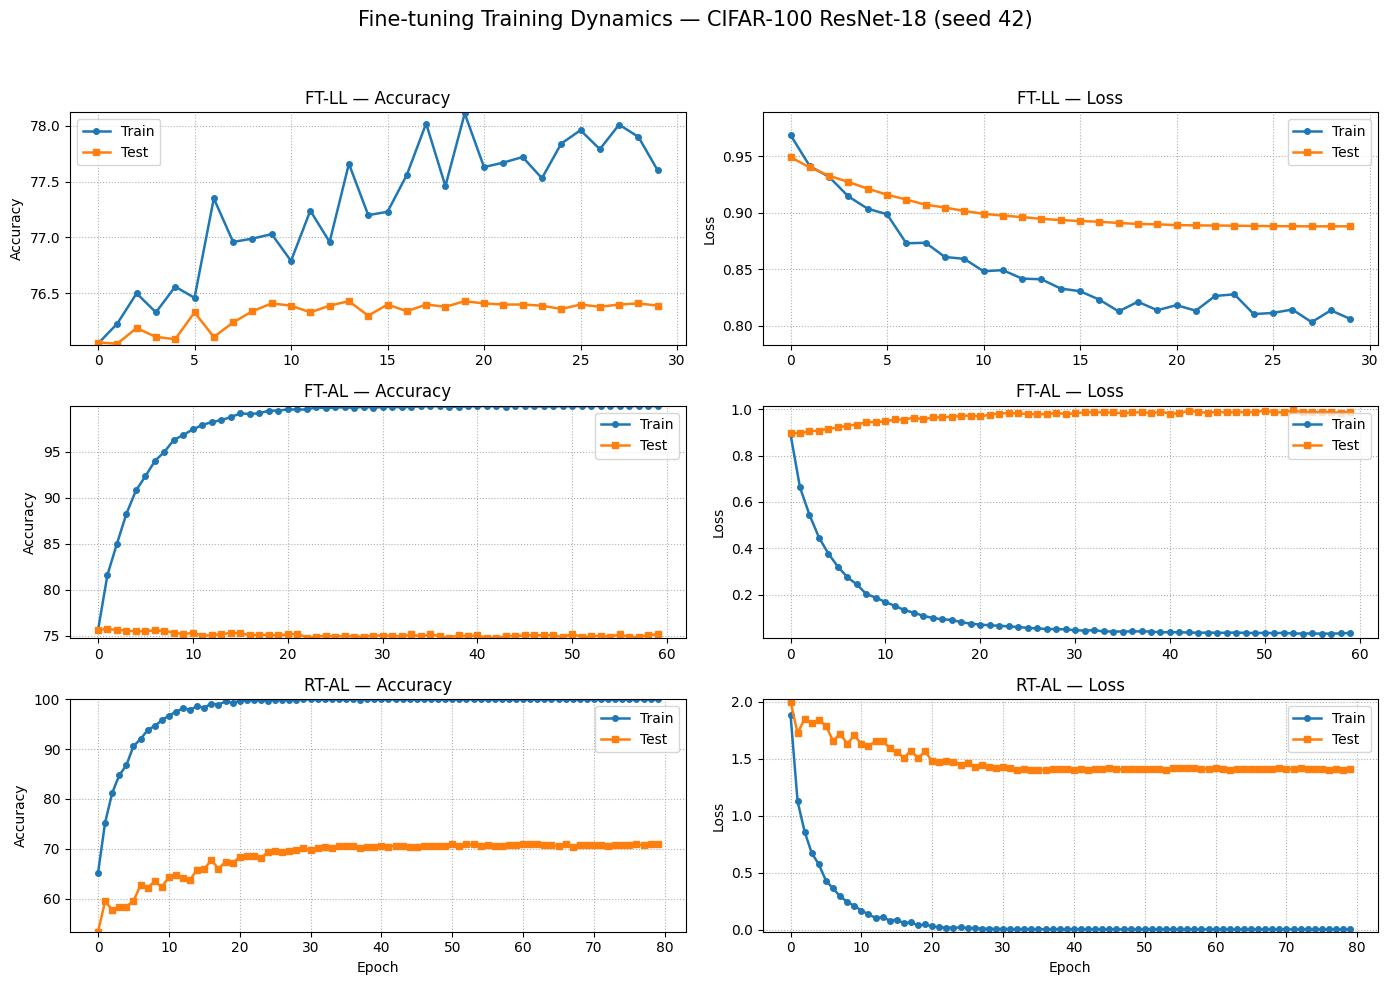

In [41]:
plot_ft_training_curves(
    dataset="CIFAR-100",
    model="ResNet-18",
    seed=42,
    log_dir="./saved_logs/fine_tune_new/Performance",
    save_fig=True
)

In [39]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt


def plot_normal_training_curves(
    dataset="CIFAR-100",
    model="ResNet-18",
    log_dir="./saved_logs/normal",
    seed=42,
    save_fig=True
):
    """
    Plot train/test accuracy and loss curves for NORMAL training.
    """

    fname = f"training_log_{dataset}_{model}_{seed}.csv"
    path = os.path.join(log_dir, fname)

    if not os.path.exists(path):
        print(f"[!] File not found: {path}")
        return

    df = pd.read_csv(path)
    if df.shape[0] == 0:
        print(f"[!] Empty CSV: {path}")
        return

    # ---- Adjust these column names if needed ----
    epochs = df["Epoch"]
    train_loss = df["Train_Loss"]
    train_acc  = df["Train_Acc"]
    test_loss  = df["Test_Loss"]
    test_acc   = df["Test_Acc"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(
        f"Normal Training — {dataset.upper()} {model.upper()} (seed={seed})",
        fontsize=14
    )

    # -------------------------
    # Accuracy
    # -------------------------
    ax = axes[0]
    ax.plot(epochs, train_acc, marker="o", markersize=4, label="Train", linewidth=1.8)
    ax.plot(epochs, test_acc,  marker="s", markersize=4, label="Test",  linewidth=1.8)
    ax.set_title("Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle=":")
    ax.legend()

    acc_min = min(train_acc.min(), test_acc.min())
    acc_max = max(train_acc.max(), test_acc.max())
    ax.set_ylim(acc_min - 0.01, acc_max + 0.01)

    # -------------------------
    # Loss
    # -------------------------
    ax = axes[1]
    ax.plot(epochs, train_loss, marker="o", markersize=4, label="Train", linewidth=1.8)
    ax.plot(epochs, test_loss,  marker="s", markersize=4, label="Test",  linewidth=1.8)
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, linestyle=":")
    ax.legend()

    loss_min = min(train_loss.min(), test_loss.min())
    loss_max = max(train_loss.max(), test_loss.max())
    ax.set_ylim(loss_min - 0.02, loss_max + 0.02)

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    if save_fig:
        outdir = "./saved_plots/normal_training"
        os.makedirs(outdir, exist_ok=True)
        outpath = os.path.join(
            outdir, f"Normal_{dataset}_{model}_seed{seed}_old.pdf"
        )
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[✓] Saved plot to {outpath}")

    plt.show()


[✓] Saved plot to ./saved_plots/normal_training\Normal_CIFAR-100_ResNet-18_seed42_old.pdf


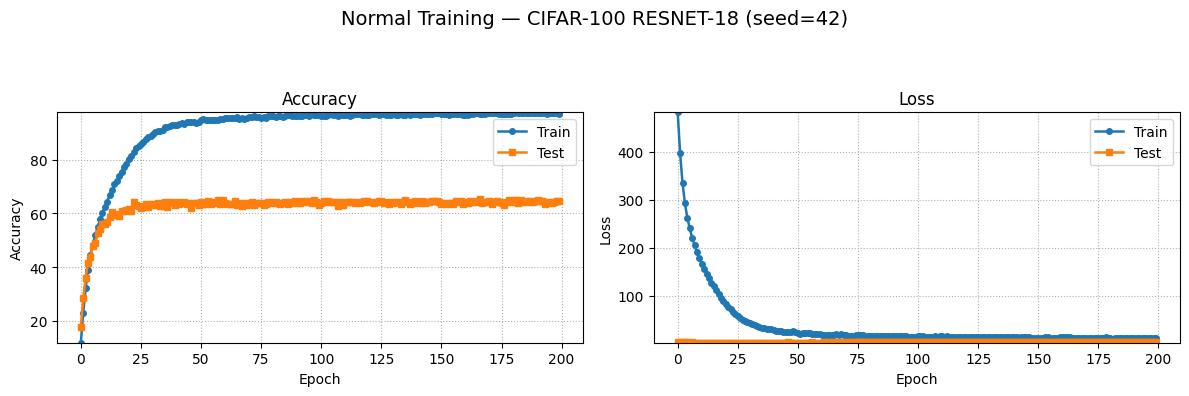

In [40]:
plot_normal_training_curves()